In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import sys
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

from project_dm_smooth_ana import iter_smooth_drdq, get_drdqz, smear_drdqz_gauss, smear_drdqz_amp_gauss

In [2]:
a, b = 1.31662664e+02, 6.33417842e-07

# def smear_drdqz_gauss(qq, drdqz, sigma_kev):
#     """Convolve spectrum with a Gaussian kernel"""
#     dq = qq[1] - qq[0]
#     qq_gauss = np.arange(-2000, 2000, dq)
#     gauss_kernel = utils.gauss(qq_gauss, A=1, mu=0, sigma=sigma_kev)

#     # Pad the array to minimize edge effect
#     # to get the rising tail when q -> 0
#     # then pad with mirror image
#     pad_len = gauss_kernel.size
#     if qq[0] >= dq:
#         padded_drdqz = np.pad(drdqz, (pad_len, 0), mode='symmetric')
#     else:
#         padded_drdqz = np.pad(drdqz, (pad_len, 0), mode='reflect')
#     padded_drdqz = np.pad(padded_drdqz, (0, pad_len), mode='constant', constant_values=0)

#     # Times the binwidth `dq` to preserve the correct normalization
#     convolved = np.convolve(padded_drdqz, gauss_kernel, mode='valid')

#     idx_start = (convolved.size - drdqz.size) // 2
#     ret = convolved[idx_start : idx_start + drdqz.size] / np.sum(gauss_kernel)

#     return qq, ret

# def sigma_q_kev(q, a, b):
#     return a + b * q**2

# def smear_drdqz_amp_gauss(qq, drdqz, a, b):
#     """Convolve spectrum with a Gaussian kernel that has an amplitude-dependent 
#     width a + b * x^2"""
#     smeared_drdqz = np.empty_like(drdqz)
#     dq = qq[1] - qq[0]

#     qq_gauss = np.arange(-2000, 2000, dq)
#     # # Pad the array to minimize edge effect
#     # # to get the rising tail when q -> 0
#     # # then pad with mirror image
#     # pad_len = qq_gauss.size
#     # if qq[0] >= dq:
#     #     padded_drdqz = np.pad(drdqz, (pad_len, 0), mode='symmetric')
#     # else:
#     #     padded_drdqz = np.pad(drdqz, (pad_len, 0), mode='reflect')
#     # padded_drdqz = np.pad(padded_drdqz, (0, pad_len), mode='constant', constant_values=0)
#     padded_drdqz = np.pad(drdqz, (pad_len, pad_len), mode='constant', constant_values=0)

#     sigma_q = sigma_q_kev(qq, a, b)
#     for i, qi in enumerate(qq):
#         sigma = sigma_q[i]
#         gauss_kernel = utils.gauss(qq_gauss, A=1, mu=0, sigma=sigma)

#         drdqz_to_convolve = padded_drdqz[pad_len//2+i : pad_len//2+i+qq_gauss.size]
#         smeared_drdqz[i] = np.sum(drdqz_to_convolve * gauss_kernel) / np.sum(gauss_kernel)
    
#     return qq, smeared_drdqz

In [3]:
R_um = 0.083
mphi = 1
data_dir = f'/home/yt388/palmer_scratch/data/dm_rate/mphi_{mphi:.0e}'

mx_list_coarse = np.logspace(-1, 4, 77)
alpha_list_coarse = np.logspace(-7, -3, 79)

mx = mx_list_coarse[30]
alpha = alpha_list_coarse[20]
mphi = 1

file = f'{data_dir}/drdq_100mevthr_nanosphere_{R_um:.2e}_{mx:.5e}_{alpha:.5e}_{mphi:.0e}.npz'
drdq_npz = np.load(file)

qq = drdq_npz['q_kev']
drdq = drdq_npz['drdq_hz_kev']

In [9]:
_qq, drdqz = get_drdqz(qq, drdq)
_qq, drdqz_smeared_gauss = smear_drdqz_gauss(_qq, drdqz, 150)
_qq, drdqz_smeared_amp_gauss = smear_drdqz_amp_gauss(_qq, drdqz, a, b)

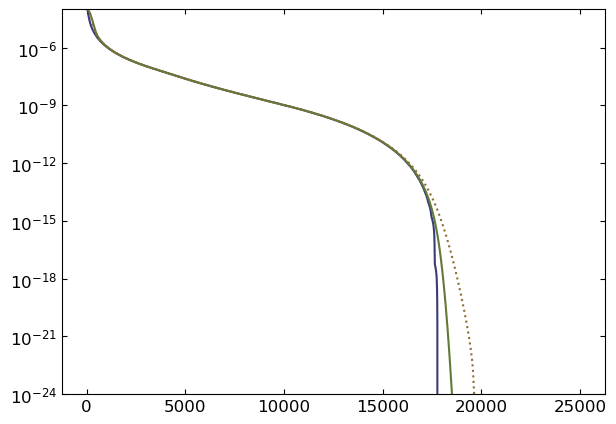

In [10]:
# plt.plot(qq, drdq, label='$dR/dq$')
plt.plot(_qq, drdqz, label='$dR/dqz$')
plt.plot(_qq, drdqz_smeared_gauss, label='$dR/dqz$, $\sigma$=150 keV')
plt.plot(_qq, drdqz_smeared_amp_gauss, ':', label='$dR/dqz$, $\sigma$ amp. dep.')

# plt.xlim(10, 2000)
plt.ylim(1e-24, 1e-4)
# plt.legend(frameon=False)
# plt.xscale('log')
plt.yscale('log')

#### Compare to Monte Carlo results

In [11]:
def get_random_q_samples(qq, drdq, rr):
    norm_factor = np.trapz(drdq, qq)

    f_drdq_norm = drdq / norm_factor    # PDF of q
    cumsum = np.cumsum(f_drdq_norm)
    Fc_drdq_norm = cumsum / cumsum[-1]  # CDF of q

    qq_sampled = np.interp(rr, Fc_drdq_norm, qq, left=0, right=0)
    return qq_sampled, norm_factor

In [12]:
qmax = max(50 * (qq[np.nonzero(drdq > 0)[0][-1]] // 50 + 2), 10000)
bins_sample = np.arange(0, qmax, 50)
bc_mc = 0.5 * (bins_sample[1:] + bins_sample[:-1])

n_mc = int(1e8)
sigma_gaus = 150
rng = np.random.default_rng()

rr = rng.uniform(0, 1, n_mc)
uu = rng.uniform(-1, 1, n_mc)
phiphi = rng.uniform(0, 2*np.pi, n_mc)
noise_gaussian = rng.normal(0, sigma_gaus, n_mc)

qq_sampled, norm = get_random_q_samples(qq, drdq, rr)

hh, be   = np.histogram(np.abs(qq_sampled), bins=np.arange(0, qmax, 50), density=True)
hhx, be  = np.histogram(np.abs(qq_sampled * np.sqrt(1 - uu**2) * np.cos(phiphi)), bins=np.arange(0, qmax, 50), density=True)
hhy, be  = np.histogram(np.abs(qq_sampled * np.sqrt(1 - uu**2) * np.sin(phiphi)), bins=np.arange(0, qmax, 50), density=True)
hhz, be  = np.histogram(np.abs(qq_sampled * uu), bins=np.arange(0, qmax, 50), density=True)
hhzn, be = np.histogram(np.abs(qq_sampled * uu + noise_gaussian), bins=bins_sample, density=True)

(1e-20, 0.01)

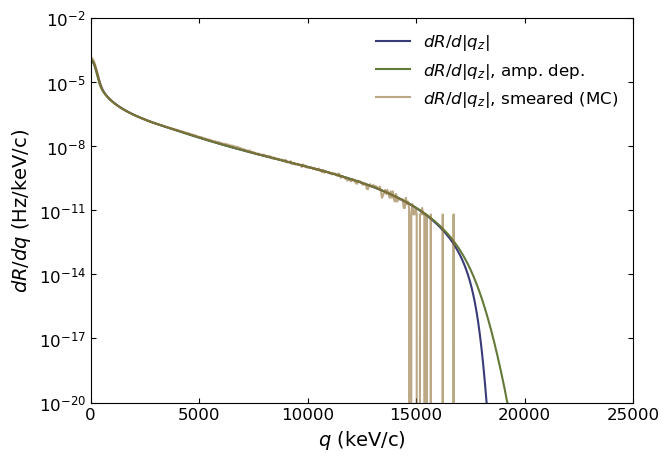

In [19]:
bc_mc = 0.5 * (bins_sample[1:] + bins_sample[:-1])

# plt.plot(qq, drdq)
# plt.plot(bc_mc, hh*norm)

# plt.plot(_qq, drdqz, label=r'$dR/d|q_z|$')
# plt.plot(bc_mc, hhz*norm, alpha=0.6, label=r'$dR/d|q_z|$ (MC)')

plt.plot(_qq, drdqz_smeared_gauss, label=r'$dR/d|q_z|$')
plt.plot(_qq, drdqz_smeared_amp_gauss, label=r'$dR/d|q_z|$, amp. dep.')
plt.plot(bc_mc, hhzn*norm, alpha=0.6, label=r'$dR/d|q_z|$, smeared (MC)')

plt.legend(frameon=False)
plt.yscale('log')
plt.xlabel('$q$ (keV/c)')
plt.ylabel('$dR/dq$ (Hz/keV/c)')

plt.xlim(0, 25000)
plt.ylim(1e-20, 1e-2)
